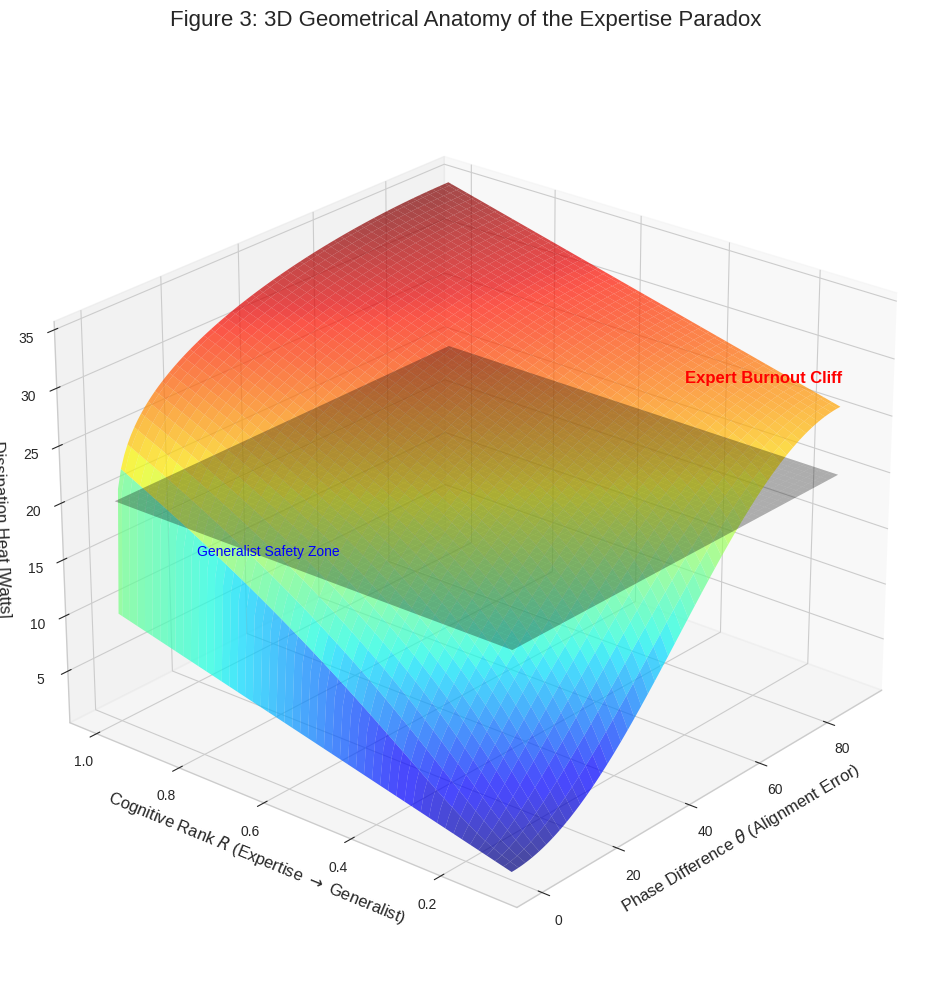

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
# Phase Difference theta (Degrees): Alignment error between AI output and cognitive manifold
theta = np.linspace(0, 90, 100)
# Cognitive Rank R (0.1: Hyper-specialized Expert, 1.0: Broad Generalist)
rank = np.linspace(0.1, 1.0, 100)
T, R = np.meshgrid(theta, rank)

# Heat Generation Function based on the Paper's Mathematical Formulation:
# Q_total = Base_Metabolism(R) + AI_Load * Projection_Error(theta, R)
# Higher Rank (Generalists) incur higher base metabolism (maintenance cost).
# Lower Rank (Experts) exhibit extreme sensitivity to theta (orthogonal dissipation).

N_ai = 25.0  # Intensity coefficient of high-dimensional AI information load (X_ai)
Base_Metabolism = 10.0 * R  # Maintenance cost increases with cognitive width (Rank)
# Geometric Projection Error: Modeling the dissipation into the orthogonal complement.
# As Rank R decreases (specialization), sensitivity to Phase Difference theta increases exponentially.
Projection_Error = N_ai * (np.sin(np.radians(T)) ** (1.0 / (R * 5.0)))

Z = Base_Metabolism + Projection_Error

# Visualization
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Surface of Dissipation Heat
surf = ax.plot_surface(T, R, Z, cmap='jet', alpha=0.7, edgecolor='none')

# --- Biological Hard Cap (20W Limit) ---
# The absolute thermodynamic threshold (P_max) beyond which structural collapse occurs.
cap = np.full_like(Z, 20.0)
ax.plot_surface(T, R, cap, color='black', alpha=0.3, label='20W Hard Cap')

# Titles and Axis Labels
ax.set_title('Figure 3: 3D Geometrical Anatomy of the Expertise Paradox', fontsize=16, pad=30)
ax.set_xlabel('Phase Difference $\\theta$ (Alignment Error)', fontsize=12)
ax.set_ylabel('Cognitive Rank $R$ (Expertise $\\to$ Generalist)', fontsize=12)
ax.set_zlabel('Dissipation Heat [Watts]', fontsize=12)

# Adjust viewpoint to emphasize the "Burnout Cliff" for specialized experts
ax.view_init(elev=25, azim=-140)

# Critical Zone Annotations
ax.text(45, 0.1, 35, "Expert Burnout Cliff", color='red', fontsize=12, fontweight='bold')
ax.text(10, 0.9, 15, "Generalist Safety Zone", color='blue', fontsize=10)

plt.tight_layout()
plt.show()